In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
train.shape

(614, 13)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
train.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [7]:
train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
train['Married'].fillna(train['Married'].mode()[0], inplace=True)
train['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
train['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)
train['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)

In [8]:
train['LoanAmount'].fillna(train['LoanAmount'].median(), inplace=True)
train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].median(), inplace=True)

In [9]:
train.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


**EDA**

Exploratory Data Analysis (EDA) is a crucial step in data science where you analyze and summarize datasets using statistical graphics and visualization methods. Its primary goal is to uncover hidden patterns, spot anomalies or outliers, and check assumptions before applying machine learning or statistical models.

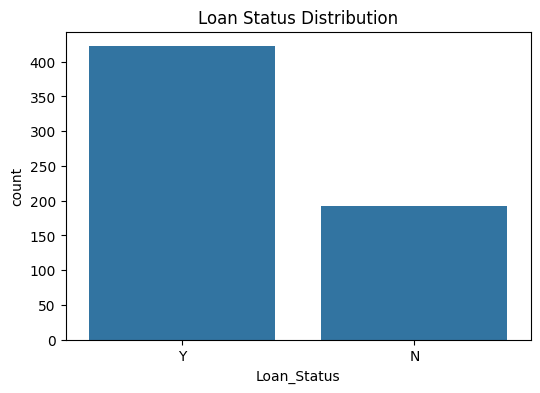

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=train)
plt.title("Loan Status Distribution")
plt.show()

Approved aur Rejected loans ka distribution dekhna.

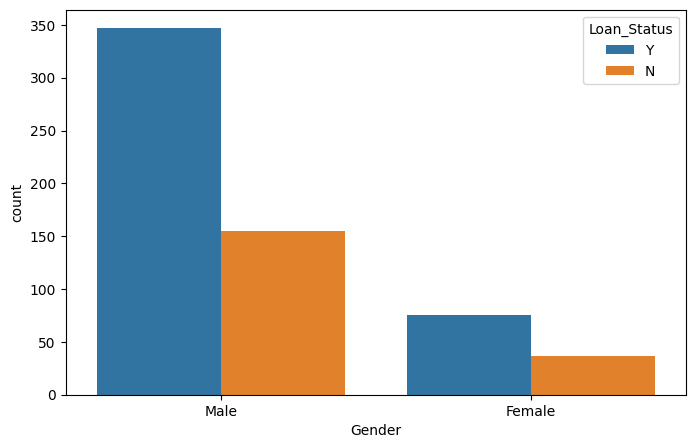

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', hue='Loan_Status', data=train)
plt.show()

Male/Female approval compare karna.

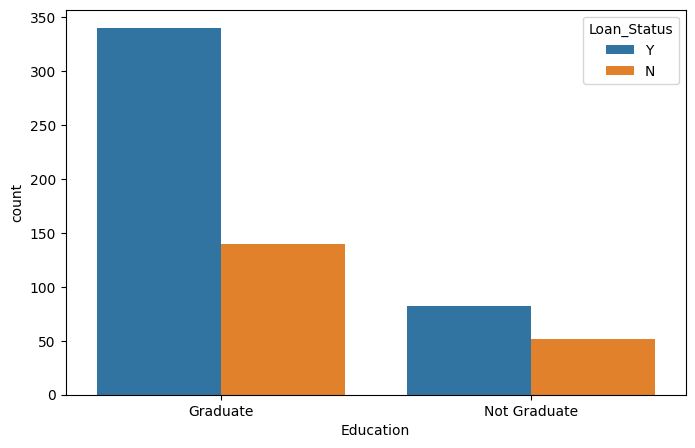

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='Education', hue='Loan_Status', data=train)
plt.show()

Education loan approval ko affect karti hai ya nahi.

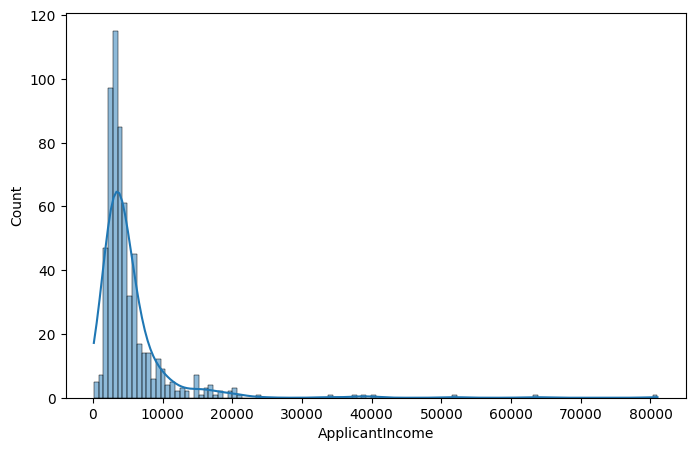

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(train['ApplicantIncome'], kde=True)
plt.show()

Income ka distribution dekhna.

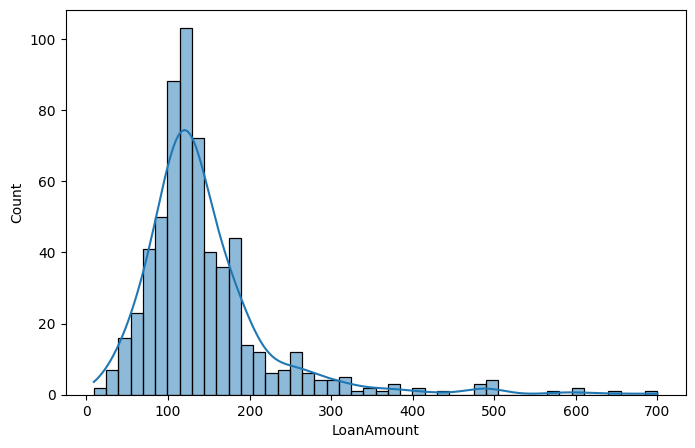

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(train['LoanAmount'], kde=True)
plt.show()

Loan amount ka spread samajhna.

**Feature Engineering**

Raw data ko directly model me dene ke bajay us data se naye informative features banaye jaate hain jo target variable ko predict karne me zyada help karte hain

In [15]:
train['TotalIncome'] = (
    train['ApplicantIncome']
    + train['CoapplicantIncome']
)

Loan approve karte waqt bank sirf applicant ki income nahi dekhta.

Wo dekhta hai

Applicant Income
Coapplicant Income

Dono milkar repayment capacity batate hain

In [16]:
train['TotalIncome_log'] = np.log(
    train['TotalIncome']
)

The TotalIncome feature had a highly right-skewed distribution. Therefore, I applied logarithmic transformation to normalize the distribution, reduce the impact of extreme values, and improve model learning.

In [17]:
train['LoanAmount_log'] = np.log(
    train['LoanAmount']
)

Loan amount also showed a right-skewed distribution, so I applied logarithmic transformation to stabilize variance and improve prediction performance

In [18]:
train['EMI'] = (
    train['LoanAmount']
    /
    train['Loan_Amount_Term']
)

Bank sirf loan amount nahi dekhta.

Wo dekhta hai

Customer ko har month kitna EMI dena padega.

In [19]:
train['Income_Loan_Ratio'] = (
    train['TotalIncome']
    /
    train['LoanAmount']
)

Bank actually ye compare karta hai

**Encoding**

In [20]:
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

In [21]:
le = LabelEncoder()

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])

Text ko numbers me convert kiya.

Kyuki ML models text samajh nahi sakte.

In [22]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,TotalIncome_log,LoanAmount_log,EMI,Income_Loan_Ratio
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,8.674026,4.852030,0.355556,45.695312
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,8.714568,4.852030,0.355556,47.585938
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,8.006368,4.189655,0.183333,45.454545
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,8.505323,4.787492,0.333333,41.175000
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,8.699515,4.948760,0.391667,42.553191


Correlation Heatmap

Features ke beech relationship dekha.

Strong positive ya negative correlation identify ki

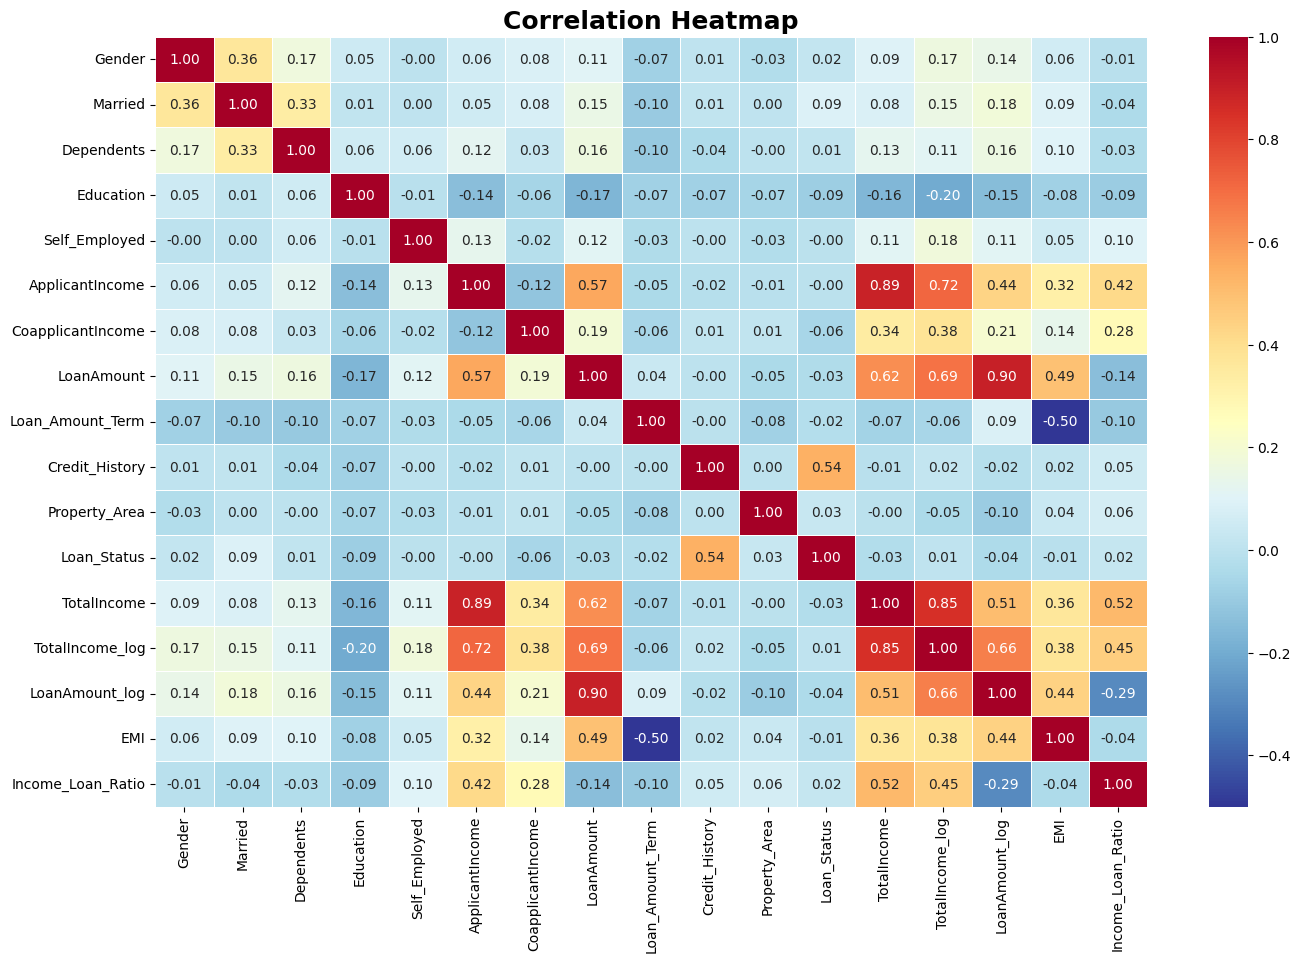

In [23]:
plt.figure(figsize=(16,10))

corr = train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.show()

Select Features


Input features aur target alag kiye

In [24]:
X = train.drop(
    ['Loan_ID','Loan_Status'],
    axis=1
)

y = train['Loan_Status']

Train Test Split

80%
Training
20%
Testing
Purpose:
Model unseen data pe kitna acha perform karta hai check karna.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

  ML
  

Data preprocessing aur feature engineering complete hone ke baad maine dataset ko training aur testing sets me divide kiya. Iske baad maine ek hi algorithm par depend na hokar 5 alag-alag Machine Learning models train kiye aur unki performance compare ki.

Models use karne ka main purpose tha ki kaunsa algorithm loan approval prediction ke liye sabse accurate aur reliable results deta hai.

Logistic Regression

Logistic Regression ek Supervised Classification Algorithm hai jo binary classification problems ke liye use hota hai.

Ye algorithm input features ki help se probability calculate karta hai ki loan approve hoga ya reject.

Probability calculate karne ke liye ye Sigmoid Function use karta hai.

In [26]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Accuracy :",lr_acc)

Accuracy : 0.7073170731707317


Decision Tree

Decision Tree ek tree-based supervised learning algorithm hai.

Ye data ko multiple conditions ke basis par split karta hai.

In [27]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print(dt_acc)

0.7073170731707317


Random Forest

Sab trees prediction karte hain.

Random Forest combines multiple Decision Trees and makes the final prediction using majority voting. This reduces overfitting and improves generalization.

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

0.7967479674796748


Gradient Boosting

Gradient Boosting builds trees sequentially, where each new tree learns from the mistakes made by previous trees. This gradually improves prediction performance

In [29]:
gb = GradientBoostingClassifier()

gb.fit(X_train,y_train)

gb_pred = gb.predict(X_test)

gb_acc = accuracy_score(
    y_test,
    gb_pred
)

print(gb_acc)

0.7967479674796748


XGBoost

XGBoost is an optimized implementation of Gradient Boosting. It provides better speed, regularization, and predictive performance. In my project, it achieved the highest accuracy, so I selected it as the final model.

In [30]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print(xgb_acc)

0.7804878048780488


Compare Models

Sabhi trained models ki performance compare ki.

In [31]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc,
        gb_acc,
        xgb_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.707317
1,Decision Tree,0.707317
2,Random Forest,0.796748
3,Gradient Boosting,0.796748
4,XGBoost,0.780488


Accuracy Chart

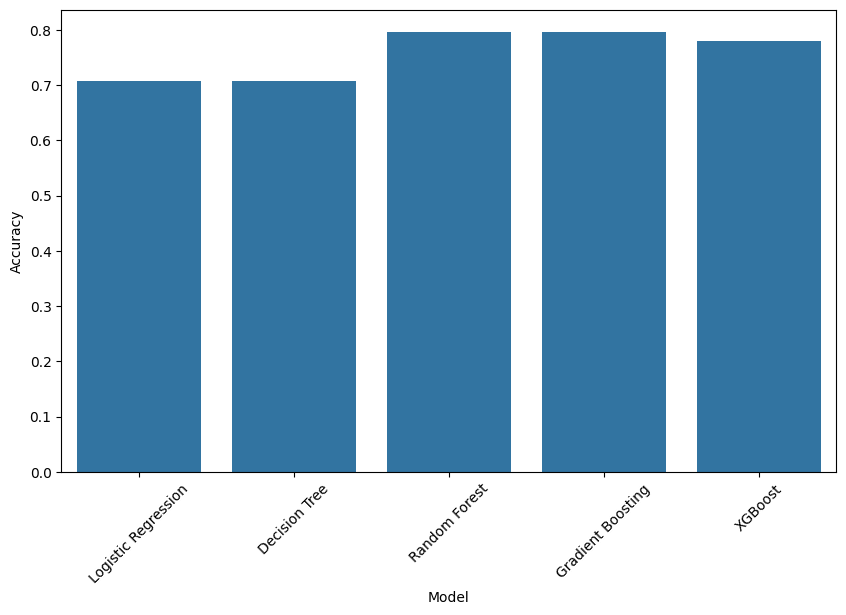

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=45)

plt.show()

Feature Importance

Feature Importance se pata chalta hai ki model kis feature par sabse zyada depend kar raha hai.

Is project me Credit_History sabse important predictor tha, kyunki jis customer ki credit history achhi hoti hai, uske loan approve hone ke chances bhi zyada hote hain.

In [33]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':
    xgb.feature_importances_
})

In [34]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

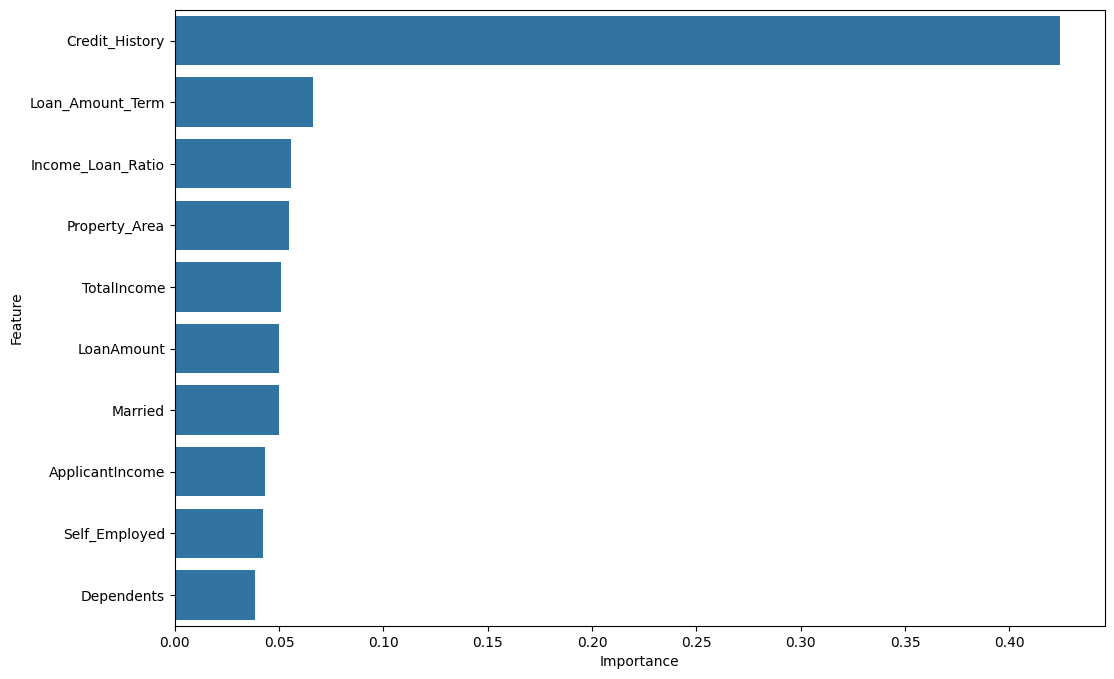

In [35]:
plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()

Classification Report

Accuracy alone misleading ho sakti hai, especially jab classes imbalanced hon. Classification Report model ka complete performance analysis provide karti hai

In [36]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.79      0.51      0.62        43
           1       0.78      0.93      0.85        80

    accuracy                           0.78       123
   macro avg       0.78      0.72      0.73       123
weighted avg       0.78      0.78      0.77       123



Confusion Matrix

Confusion Matrix se prediction errors ko detail me samjha ja sakta hai aur ye identify kiya ja sakta hai ki model kis type ki mistakes zyada kar raha hai.

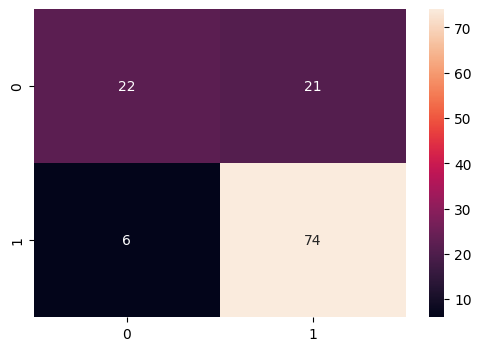

In [37]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [38]:
# Clean dataset save karo
train.to_csv("clean_dataset.csv", index=False)

In [39]:
from google.colab import files

files.download("clean_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
import joblib

joblib.dump(
    xgb,
    'best_model.pkl'
)

['best_model.pkl']

In [41]:
joblib.dump(
    X.columns.tolist(),
    'features.pkl'
)

['features.pkl']

In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.78861789 0.7804878  0.81300813 0.82926829 0.78688525]
0.7996534719445554


"SHAP" har feature ka prediction me contribution batata hai. Agar kisi applicant ka loan approve hua, to SHAP ye dikha sakta hai ki Credit History, Total Income, EMI ya Loan Amount me se kis feature ne approval ya rejection me kitna positive ya negative effect dala.

In [43]:
!pip install shap

In [44]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)

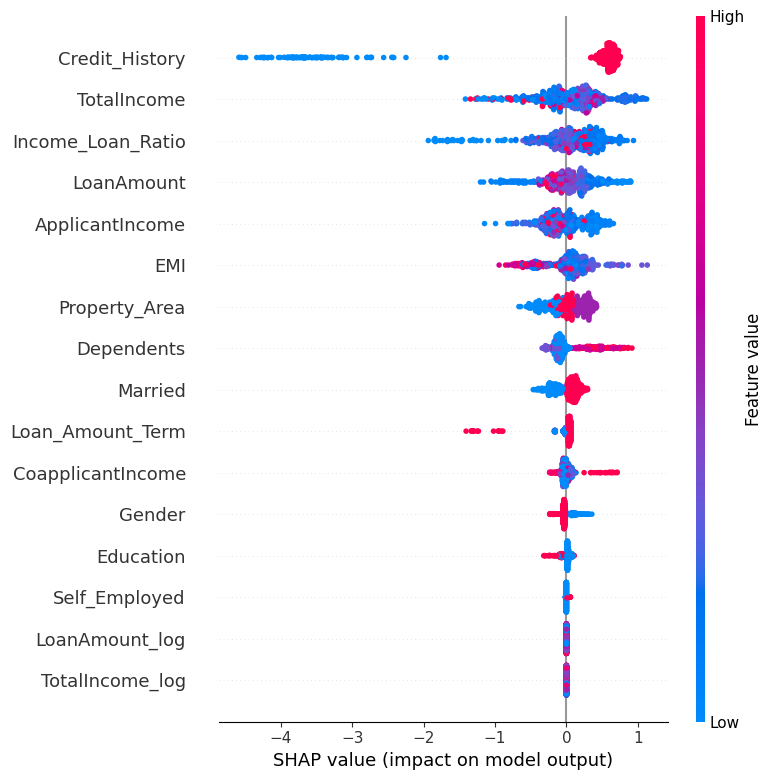

In [45]:
shap.summary_plot(
    shap_values,
    X
)

In [46]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 38.9 MB/s eta 0:00:00


In [47]:
!pip install streamlit pyngrok

In [48]:
!pip install pyngrok

In [49]:
from pyngrok import ngrok

ngrok.set_auth_token("3Fp9dKWZorxWCQ5Sh7Z2gE1CLqf_7RBUqE7V4SNEEQenvcorm")

In [50]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

import plotly.express as px
import plotly.graph_objects as go


st.set_page_config(
    page_title="Loan Approval Prediction",
    page_icon="🏦",
    layout="wide"
)


model = joblib.load("/content/best_model.pkl")
feature_columns = joblib.load("/content/features.pkl")

df = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")



df['TotalIncome'] = (
    df['ApplicantIncome']
    +
    df['CoapplicantIncome']
)

df['TotalIncome_log'] = np.log(df['TotalIncome'])

df['LoanAmount_log'] = np.log(df['LoanAmount'])

df['EMI'] = (
    df['LoanAmount']
    /
    df['Loan_Amount_Term']
)

df['Income_Loan_Ratio'] = (
    df['TotalIncome']
    /
    df['LoanAmount']
)



st.sidebar.title("🏦 Navigation")

page = st.sidebar.radio(
    "Go To",
    [
        "Home",
        "Dataset",
        "EDA Dashboard",
        "Prediction"
    ]
)


# ==========================
# HOME PAGE
# ==========================

if page == "Home":

    st.title("🏦 Loan Approval Prediction System")
    st.markdown("---")

    st.markdown("""
    ### 📌 Project Overview

    This Machine Learning application predicts whether a loan application
    is likely to be approved or rejected based on applicant details such as
    income, loan amount, credit history, education, and property area.

    The model has been trained using multiple machine learning algorithms,
    with the best-performing model selected for deployment.
    """)

    st.markdown("")

    total_records = len(df)
    total_features = df.shape[1]

    approved_loans = df[df["Loan_Status"] == 1].shape[0]
    rejected_loans = total_records - approved_loans

    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            label="📊 Total Records",
            value=f"{total_records:,}"
        )

    with col2:
        st.metric(
            label="📂 Features",
            value=total_features
        )

    with col3:
        st.metric(
            label="✅ Approved Loans",
            value=approved_loans
        )

    with col4:
        st.metric(
            label="❌ Rejected Loans",
            value=rejected_loans
        )

    st.markdown("---")

    try:
        st.image(
            "/content/bank.jpeg",
            caption="AI Powered Loan Approval Prediction",
            use_container_width=True
        )
    except:
        st.warning("Banner image not found.")

    st.markdown("---")


    st.subheader("🚀 Key Features")

    feature1, feature2, feature3 = st.columns(3)

    with feature1:
        st.info("""
        **📈 Data Analysis**

        Explore applicant demographics,
        income patterns and loan trends.
        """)

    with feature2:
        st.success("""
        **🤖 ML Prediction**

        Predict loan approval using
        trained machine learning models.
        """)

    with feature3:
        st.warning("""
        **📊 Interactive Dashboard**

        Visualize insights through
        interactive charts and metrics.
        """)

    st.markdown("---")

    st.subheader("🛠 Technologies Used")

    st.write("""
    - Python
    - Pandas
    - NumPy
    - Scikit-Learn
    - XGBoost
    - Plotly
    - Streamlit
    - Machine Learning
    """)

    st.markdown("---")

    st.success("🎯 Navigate using the sidebar to explore the dashboard and make predictions.")

elif page == "Dataset":

    st.title("📊 Dataset Overview")

    st.subheader("Dataset Shape")

    st.write(df.shape)

    st.subheader("First 10 Rows")

    st.dataframe(df.head(10))

    st.subheader("Statistical Summary")

    st.dataframe(df.describe())


elif page == "EDA Dashboard":

    st.title("📈 Exploratory Data Analysis")

    col1,col2 = st.columns(2)

    with col1:

        loan_status = px.histogram(
            df,
            x="Loan_Status",
            title="Loan Status Distribution"
        )

        st.plotly_chart(
            loan_status,
            use_container_width=True
        )

    with col2:

        gender = px.histogram(
            df,
            x="Gender",
            color="Loan_Status",
            title="Gender vs Loan Status"
        )

        st.plotly_chart(
            gender,
            use_container_width=True
        )

    st.divider()

    income = px.histogram(
        df,
        x="ApplicantIncome",
        title="Applicant Income Distribution"
    )

    st.plotly_chart(
        income,
        use_container_width=True
    )

    area = px.histogram(
        df,
        x="Property_Area",
        color="Loan_Status",
        title="Property Area Analysis"
    )

    st.plotly_chart(
        area,
        use_container_width=True
    )

elif page == "Prediction":

    st.title("🤖 Loan Approval Prediction")

    col1,col2 = st.columns(2)

    with col1:

        gender = st.selectbox(
            "Gender",
            ["Male","Female"]
        )

        married = st.selectbox(
            "Married",
            ["Yes","No"]
        )

        dependents = st.selectbox(
            "Dependents",
            ["0","1","2","3+"]
        )

        education = st.selectbox(
            "Education",
            ["Graduate","Not Graduate"]
        )

        self_emp = st.selectbox(
            "Self Employed",
            ["Yes","No"]
        )

    with col2:

        applicant_income = st.number_input(
            "Applicant Income",
            value=5000
        )

        co_income = st.number_input(
            "Coapplicant Income",
            value=0
        )

        loan_amount = st.number_input(
            "Loan Amount",
            value=120
        )

        loan_term = st.number_input(
            "Loan Term",
            value=360
        )

        credit_history = st.selectbox(
            "Credit History",
            [1,0]
        )

        property_area = st.selectbox(
            "Property Area",
            ["Urban","Semiurban","Rural"]
        )

    if st.button("Predict Loan Status"):

        total_income = (
            applicant_income
            +
            co_income
        )

        total_income_log = np.log(
            total_income
        )

        loan_amount_log = np.log(
            loan_amount
        )

        emi = (
            loan_amount
            /
            loan_term
        )

        income_loan_ratio = (
            total_income
            /
            loan_amount
        )

        input_df = pd.DataFrame({

            'Gender':[1 if gender=="Male" else 0],

            'Married':[1 if married=="Yes" else 0],

            'Dependents':[0],

            'Education':[1 if education=="Graduate" else 0],

            'Self_Employed':[1 if self_emp=="Yes" else 0],

            'ApplicantIncome':[applicant_income],

            'CoapplicantIncome':[co_income],

            'LoanAmount':[loan_amount],

            'Loan_Amount_Term':[loan_term],

            'Credit_History':[credit_history],

            'Property_Area':[2],

            'TotalIncome':[total_income],

            'TotalIncome_log':[total_income_log],

            'LoanAmount_log':[loan_amount_log],

            'EMI':[emi],

            'Income_Loan_Ratio':[income_loan_ratio]
        })

        prediction = model.predict(
            input_df
        )[0]

        probability = (
            model.predict_proba(
                input_df
            )[0].max()*100
        )

        if prediction == 1:

            st.success(
                f"✅ Loan Approved\n\nConfidence : {probability:.2f}%"
            )

        else:

            st.error(
                f"❌ Loan Rejected\n\nConfidence : {probability:.2f}%"
            )

Writing app.py


In [51]:
!streamlit run app.py &>/dev/null &

In [52]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://shaded-available-oversweet.ngrok-free.dev" -> "http://localhost:8501"
